In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [9]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

data = data.sort_values('Order Date')

In [10]:
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()

print(daily_sales.head())

  Order Date     Sales
0 2014-01-03    16.448
1 2014-01-04   288.060
2 2014-01-05    19.536
3 2014-01-06  4407.100
4 2014-01-07    87.158


In [11]:
daily_sales['year'] = daily_sales['Order Date'].dt.year
daily_sales['month'] = daily_sales['Order Date'].dt.month
daily_sales['day'] = daily_sales['Order Date'].dt.day
daily_sales['day_of_week'] = daily_sales['Order Date'].dt.dayofweek


In [12]:
X = daily_sales[['year','month','day','day_of_week']]
y = daily_sales['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
predictions = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1445.4385021707449


In [17]:
last_date = daily_sales['Order Date'].max()

future_dates = pd.date_range(start=last_date, periods=30)

future_df = pd.DataFrame({'Order Date': future_dates})

future_df['year'] = future_df['Order Date'].dt.year
future_df['month'] = future_df['Order Date'].dt.month
future_df['day'] = future_df['Order Date'].dt.day
future_df['day_of_week'] = future_df['Order Date'].dt.dayofweek

In [18]:
future_sales = model.predict(future_df[['year','month','day','day_of_week']])

future_df['Predicted Sales'] = future_sales

print(future_df.head())

  Order Date  year  month  day  day_of_week  Predicted Sales
0 2017-12-30  2017     12   30            5      3132.417850
1 2017-12-31  2017     12   31            6      3155.064490
2 2018-01-01  2018      1    1            0      1568.119975
3 2018-01-02  2018      1    2            1      1590.766615
4 2018-01-03  2018      1    3            2      1613.413255


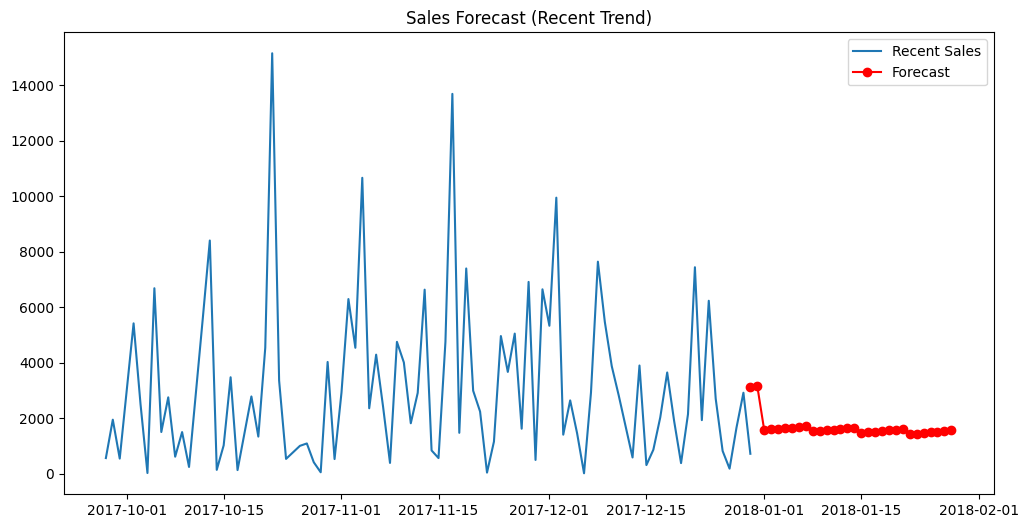

In [22]:
recent_data = daily_sales.tail(90)

plt.figure(figsize=(12,6))

plt.plot(recent_data['Order Date'], recent_data['Sales'], label="Recent Sales")

plt.plot(future_df['Order Date'], future_df['Predicted Sales'], 
         color='red', marker='o', label="Forecast")

plt.title("Sales Forecast (Recent Trend)")
plt.legend()

plt.show()

In [20]:
future_df.to_csv("future_sales_forecast.csv", index=False)